<a href="https://colab.research.google.com/github/chtmnPlfy/Coffee-in-Trend/blob/main/Consumption.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
except ImportError:
    print("Not running in Google Colab — skipping drive mount.")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Top 5 Green Coffee Domestic Consumption — Marketing Year 2024/2025

In [ ]:
import os
import glob
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
data_path = "/content/drive/MyDrive/COFFEE IN TREND/CONTENT/Latest Trend/green_coffee_domestic_consumption_2024.csv"

if not os.path.exists(data_path):
    print(f"File not found at exact path: {data_path}")
    # Fall back to a recursive search under the project folder
    matches = glob.glob(
        "/content/drive/MyDrive/COFFEE IN TREND/**/green_coffee_domestic_consumption_2024.csv",
        recursive=True,
    )
    if matches:
        print("Found file instead at:")
        for m in matches:
            print(" -", m)
        data_path = matches[0]
    else:
        raise FileNotFoundError(
            "Could not locate green_coffee_domestic_consumption_2024.csv "
            "anywhere under 'COFFEE IN TREND' on Google Drive."
        )
else:
    print(f"File found: {data_path}")


File found: /content/drive/MyDrive/COFFEE IN TREND/CONTENT/Latest Trend/green_coffee_domestic_consumption_2024.csv


In [ ]:
df = pd.read_csv(data_path)
df = df.copy()
df["Country"] = df["Country"].replace("Viet Nam", "Vietnam")
value_col = "Domestic Consumption (1000 60 KG BAGS)"
kg_col = "Domestic Consumption (KG)"
df[kg_col] = df[value_col] * 60_000
df

,Rank,Country,Domestic Consumption (1000 60 KG BAGS),Domestic Consumption (KG)
0,1,EU-27,42046,2522760000
1,2,United States,23950,1437000000
2,3,Brazil,22670,1360200000
3,4,Japan,7176,430560000
4,5,Philippines,6550,393000000
...,...,...,...,...
66,67,Guinea,15,900000
67,68,Angola,10,600000
68,69,Sierra Leone,10,600000
69,70,Senegal,5,300000


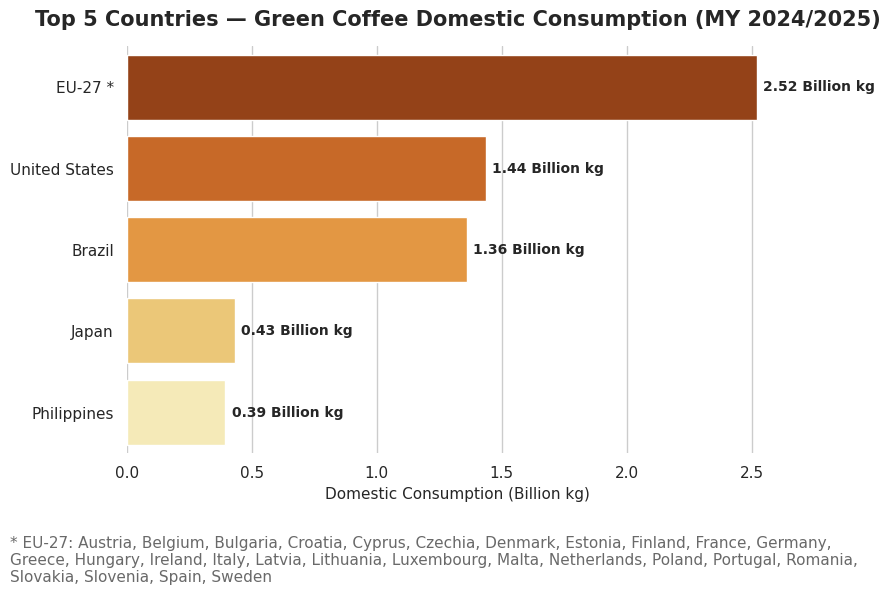

      Country  Domestic Consumption (1000 60 KG BAGS)  Domestic Consumption (KG)  Domestic Consumption (Billion kg)
        EU-27                                   42046                 2522760000                            2.52276
United States                                   23950                 1437000000                            1.43700
       Brazil                                   22670                 1360200000                            1.36020
        Japan                                    7176                  430560000                            0.43056
  Philippines                                    6550                  393000000                            0.39300


In [ ]:
top5 = df.nlargest(5, kg_col).sort_values(kg_col, ascending=False)

top5["Label"] = top5["Country"].apply(lambda c: f"{c} *" if c == "EU-27" else c)


def auto_si_mass(value_kg: float):
    units = [
        (1, "kg"),
        (1e3, "Thousand kg"),
        (1e6, "Million kg"),
        (1e9, "Billion kg"),
        (1e12, "Thousand billion kg"),
    ]
    factor, unit = units[0]
    for f, u in units:
        if value_kg >= f:
            factor, unit = f, u
        else:
            break
    return factor, unit

factor, unit = auto_si_mass(top5[kg_col].max())
si_col = f"Domestic Consumption ({unit})"
top5[si_col] = top5[kg_col] / factor

EU27_MEMBERS = [
    "Austria", "Belgium", "Bulgaria", "Croatia", "Cyprus", "Czechia",
    "Denmark", "Estonia", "Finland", "France", "Germany", "Greece",
    "Hungary", "Ireland", "Italy", "Latvia", "Lithuania", "Luxembourg",
    "Malta", "Netherlands", "Poland", "Portugal", "Romania", "Slovakia",
    "Slovenia", "Spain", "Sweden",
]

sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(9, 6))

palette = sns.color_palette("YlOrBr", n_colors=5)[::-1]
bars = sns.barplot(
    data=top5,
    x=si_col,
    y="Label",
    hue="Label",
    palette=palette,
    legend=False,
    ax=ax,
)


for i, (value, country) in enumerate(zip(top5[si_col], top5["Label"])):
    ax.text(value + top5[si_col].max() * 0.01, i, f"{value:,.2f} {unit}",
            va="center", fontsize=10, fontweight="bold")

ax.set_title("Top 5 Countries — Green Coffee Domestic Consumption (MY 2024/2025)",
              fontsize=15, fontweight="bold", pad=15)
ax.set_xlabel(f"Domestic Consumption ({unit})", fontsize=11)
ax.set_ylabel("")
sns.despine(left=True, bottom=True)


footnote = "* EU-27: " + ", ".join(EU27_MEMBERS)
fig.text(0.02, 0.02, footnote, fontsize=11, color="dimgray", wrap=True)

plt.tight_layout(rect=[0, 0.12, 1, 1])
plt.savefig("top5_domestic_consumption_2024_2025.png", dpi=300)
plt.show()

print(top5[["Country", value_col, kg_col, si_col]].to_string(index=False))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
File found: /content/drive/MyDrive/COFFEE IN TREND/CONTENT/Latest Trend/green_coffee_domestic_consumption_2024.csv
File found: /content/drive/MyDrive/COFFEE IN TREND/CONTENT/Latest Trend/world_population.csv
Countries with no population match (excluded from per-capita ranking): ['Taiwan, Province Of China']


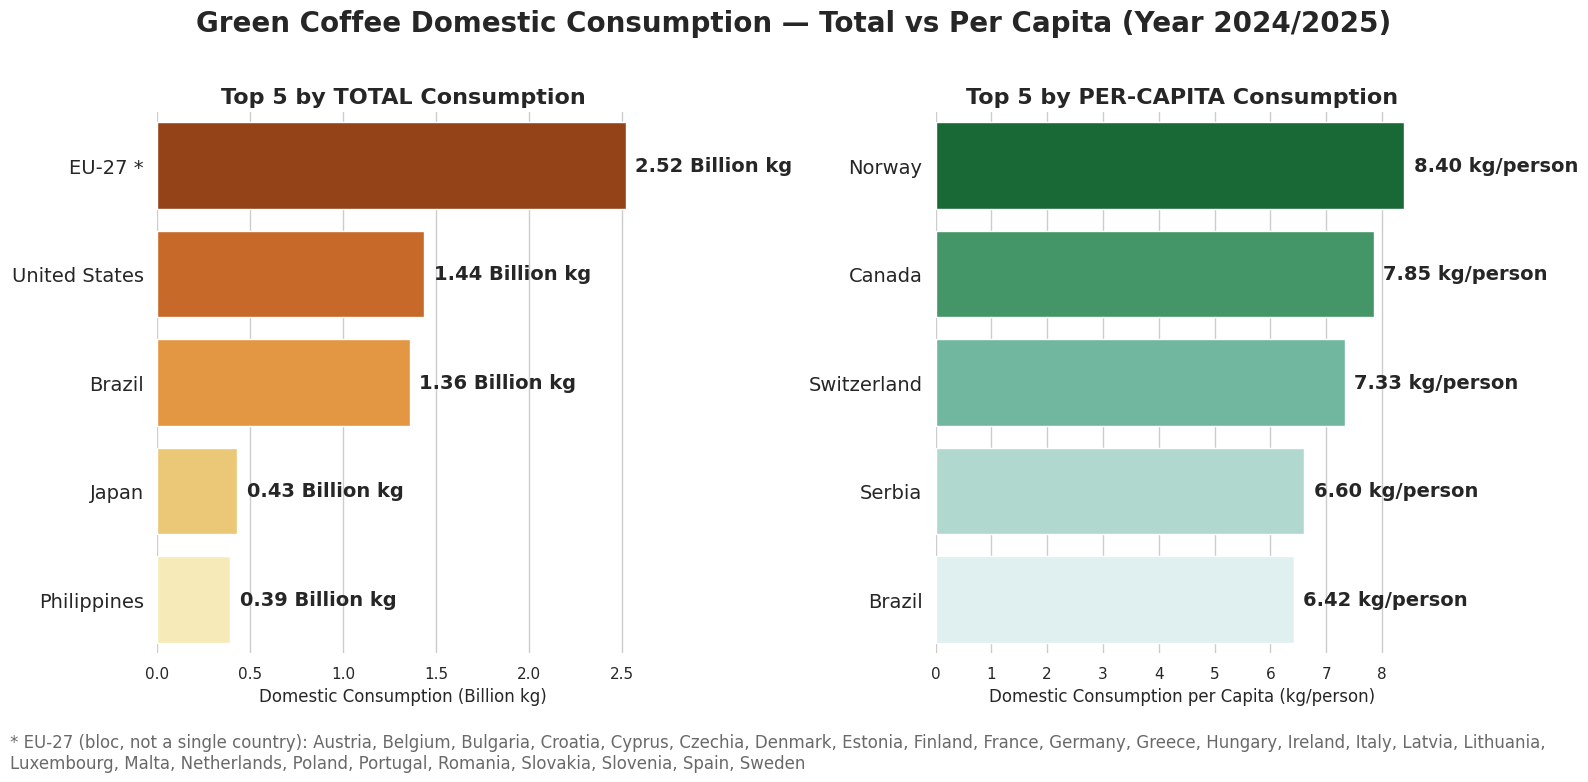


--- OLD (Total) Top 5 ---
      Country  Billion kg
        EU-27     2.52276
United States     1.43700
       Brazil     1.36020
        Japan     0.43056
  Philippines     0.39300

--- NEW (Per Capita) Top 5 ---
    Country  Population  Per Capita (kg)
     Norway   5572279.0         8.398718
     Canada  41262329.0         7.852199
Switzerland   9005582.0         7.328788
     Serbia   6586476.0         6.604442
     Brazil 211998573.0         6.416081


In [ ]:
import os
import glob
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

try:
    from google.colab import drive
    drive.mount('/content/drive')
except ImportError:
    print("Not running in Google Colab — skipping drive mount.")

BASE_DIR = "/content/drive/MyDrive/COFFEE IN TREND/CONTENT/Latest Trend"
CONSUMPTION_FILE = "green_coffee_domestic_consumption_2024.csv"
POPULATION_FILE = "world_population.csv"


def locate_file(filename, base_dir=BASE_DIR):
    exact = os.path.join(base_dir, filename)
    if os.path.exists(exact):
        print(f"File found: {exact}")
        return exact
    print(f"File not found at exact path: {exact}")
    matches = glob.glob(f"/content/drive/MyDrive/**/{filename}", recursive=True)
    if matches:
        print(f"Found instead at: {matches[0]}")
        return matches[0]
    raise FileNotFoundError(f"Could not locate {filename} anywhere on Google Drive.")


consumption_path = locate_file(CONSUMPTION_FILE) if os.path.isdir("/content/drive") else CONSUMPTION_FILE
population_path = locate_file(POPULATION_FILE) if os.path.isdir("/content/drive") else POPULATION_FILE


cons = pd.read_csv(consumption_path)
value_col = "Domestic Consumption (1000 60 KG BAGS)"

cons = cons.copy()
kg_col = "Consumption (KG)"
cons[kg_col] = cons[value_col] * 60_000


pop = pd.read_csv(population_path, skiprows=4)
pop_2024 = pop[["Country Name", "2024"]].rename(
    columns={"Country Name": "PopCountry", "2024": "Population"}
)


NAME_MAP = {
    "Korea, Republic Of": "Korea, Rep.",
    "Iran, Islamic Republic Of": "Iran, Islamic Rep.",
    "Congo, The Democratic Republic Of The": "Congo, Dem. Rep.",
    "Lao People's Democratic Republic": "Lao PDR",
    "Macedonia, The Former Yugoslav Republic Of": "North Macedonia",
    "Tanzania, United Republic Of": "Tanzania",
    "Côte D'ivoire": "Cote d'Ivoire",
    "Egypt": "Egypt, Arab Rep.",
    "Venezuela": "Venezuela, RB",
    "Turkey": "Turkiye",
    "EU-27": "European Union",
}
cons["PopCountry"] = cons["Country"].replace(NAME_MAP)


df = cons.merge(pop_2024, on="PopCountry", how="left")
df["Per Capita (kg)"] = df[kg_col] / df["Population"]

print(f"Countries with no population match (excluded from per-capita ranking): "
      f"{df.loc[df['Population'].isna(), 'Country'].tolist()}")


old_top5 = df.nlargest(5, kg_col).sort_values(kg_col, ascending=False).copy()
old_top5["Billion kg"] = old_top5[kg_col] / 1e9

new_top5 = (
    df.dropna(subset=["Per Capita (kg)"])
    .nlargest(5, "Per Capita (kg)")
    .sort_values("Per Capita (kg)", ascending=False)
    .copy()
)

for d in (old_top5, new_top5):
    d["Label"] = d["Country"].apply(lambda c: f"{c} *" if c == "EU-27" else c)

EU27_MEMBERS = [
    "Austria", "Belgium", "Bulgaria", "Croatia", "Cyprus", "Czechia",
    "Denmark", "Estonia", "Finland", "France", "Germany", "Greece",
    "Hungary", "Ireland", "Italy", "Latvia", "Lithuania", "Luxembourg",
    "Malta", "Netherlands", "Poland", "Portugal", "Romania", "Slovakia",
    "Slovenia", "Spain", "Sweden",
]
FOOTNOTE = "* EU-27 (bloc, not a single country): " + ", ".join(EU27_MEMBERS)


sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

ax = axes[0]
palette_old = sns.color_palette("YlOrBr", n_colors=5)[::-1]
sns.barplot(data=old_top5, x="Billion kg", y="Label", hue="Label",
            palette=palette_old, legend=False, ax=ax)
for i, v in enumerate(old_top5["Billion kg"]):
    ax.text(v + old_top5["Billion kg"].max() * 0.02, i, f"{v:,.2f} Billion kg",
            va="center", fontsize=14, fontweight="bold")
ax.set_title("Top 5 by TOTAL Consumption", fontsize=16, fontweight="bold")
ax.set_xlabel("Domestic Consumption (Billion kg)", fontsize=12)
ax.set_ylabel("")
ax.tick_params(axis="y", labelsize=14)

ax = axes[1]
palette_new = sns.color_palette("BuGn", n_colors=5)[::-1]
sns.barplot(data=new_top5, x="Per Capita (kg)", y="Label", hue="Label",
            palette=palette_new, legend=False, ax=ax)
for i, v in enumerate(new_top5["Per Capita (kg)"]):
    ax.text(v + new_top5["Per Capita (kg)"].max() * 0.02, i, f"{v:,.2f} kg/person",
            va="center", fontsize=14, fontweight="bold")
ax.set_title("Top 5 by PER-CAPITA Consumption", fontsize=16, fontweight="bold")
ax.set_xlabel("Domestic Consumption per Capita (kg/person)", fontsize=12)
ax.set_ylabel("")
ax.tick_params(axis="y", labelsize=14)

fig.suptitle("Green Coffee Domestic Consumption — Total vs Per Capita (Year 2024/2025)",
              fontsize=20, fontweight="bold", y=1.02)

for a in axes:
    sns.despine(ax=a, left=True, bottom=True)

fig.text(0.01, -0.06, FOOTNOTE, fontsize=12, color="dimgray", wrap=True)

plt.tight_layout()
plt.savefig(
    "top5_total_vs_percapita_consumption.png",
    dpi=200,
    bbox_inches="tight",
    pad_inches=0.3,
)
plt.show()

print("\n--- OLD (Total) Top 5 ---")
print(old_top5[["Country", "Billion kg"]].to_string(index=False))
print("\n--- NEW (Per Capita) Top 5 ---")
print(new_top5[["Country", "Population", "Per Capita (kg)"]].to_string(index=False))

In [ ]:
df

,Rank,Country,Domestic Consumption (1000 60 KG BAGS),Consumption (KG),PopCountry,Population,Per Capita (kg)
0,1,EU-27,42046,2522760000,European Union,450228188.0,5.603292
1,2,United States,23950,1437000000,United States,340003797.0,4.226423
2,3,Brazil,22670,1360200000,Brazil,211998573.0,6.416081
3,4,Japan,7176,430560000,Japan,123975371.0,3.472948
4,5,Philippines,6550,393000000,Philippines,115843670.0,3.392503
...,...,...,...,...,...,...,...
66,67,Guinea,15,900000,Guinea,14754785.0,0.060997
67,68,Angola,10,600000,Angola,37885849.0,0.015837
68,69,Sierra Leone,10,600000,Sierra Leone,8642022.0,0.069428
69,70,Senegal,5,300000,Senegal,18501984.0,0.016214


In [ ]:
COUNTRY = "Thailand"

# --- 1. Load data ---
cons = pd.read_csv(consumption_path)
pop = pd.read_csv(population_path, skiprows=4)

# --- 2. Merge consumption with population, compute per-capita (kg/person) ---
pop_2024 = pop[["Country Name", "2024"]].rename(
    columns={"Country Name": "Country", "2024": "Population"}
)
df = cons.merge(pop_2024, on="Country", how="left")
df["Consumption (KG)"] = df["Domestic Consumption (1000 60 KG BAGS)"] * 60_000
df["Per Capita (kg)"] = df["Consumption (KG)"] / df["Population"]

# --- 3. Rank by total consumption and by per-capita consumption ---
df["Rank_Total"] = df["Domestic Consumption (1000 60 KG BAGS)"].rank(ascending=False, method="min").astype(int)
df["Rank_PerCapita"] = df["Per Capita (kg)"].rank(ascending=False, method="min")

# --- 4. Show Thailand's numbers ---
row = df[df["Country"] == COUNTRY].iloc[0]

print(f"{COUNTRY} — Domestic Consumption: {row['Domestic Consumption (1000 60 KG BAGS)']:,} "
      f"(1000 60kg bags)  |  Rank {row['Rank_Total']} of {len(df)}")

print(f"{COUNTRY} — Per Capita Consumption: {row['Per Capita (kg)']:.3f} kg/person  |  "
      f"Rank {int(row['Rank_PerCapita'])} of {df['Per Capita (kg)'].notna().sum()}")

Thailand — Domestic Consumption: 925 (1000 60kg bags)  |  Rank 24 of 71
Thailand — Per Capita Consumption: 0.774 kg/person  |  Rank 37 of 59
